<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/computer_vision/watermark_removal_autoencoder/Watermark_removal_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from keras.models import Model
from keras import utils
from keras.layers import Conv2D, MaxPooling2D, Dense, Input, UpSampling2D, Conv2DTranspose, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from sklearn.model_selection import train_test_split
import random
import gc

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/watermarked.zip
!unzip -qo "watermarked.zip" -d ./watermarked

--2026-04-17 08:20:32--  https://storage.yandexcloud.net/academy.ai/watermarked.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 731796045 (698M) [application/x-zip-compressed]
Saving to: ‘watermarked.zip’

watermarked.zip     100%[===================>] 697.89M  12.5MB/s    in 50s     

2026-04-17 08:21:23 (13.9 MB/s) - ‘watermarked.zip’ saved [731796045/731796045]



In [ ]:
train_path = './watermarked/wm-nowm/train' # тренировочные образцы
valid_path = './watermarked/wm-nowm/valid' # контрольные образцы
train_path_no = os.path.join(train_path, 'no-watermark')
valid_path_no = os.path.join(valid_path, 'no-watermark')

train_nonwatermarked = [] # без водяных знаков (тренировочная выборка)
valid_nonwatermarked = [] # без водяных знаков (контрольная выборка)

# Удалим несоответствие
try:
    os.remove('./watermarked/wm-nowm/train/watermark/animal-dog-pet-cute.jpg')
except Exception as e:
    print(e) # вывод ошибки загрузки или масштабирования картинки

In [ ]:
# Размер преобразованных картинок
width = 252
height = 188
dim = (width, height)

# Функция загрузки и масштабирования картинок
def createPixelArr(files):
    data = []
    for image in files: # цикл по каждой картинке в списке
        try:
            # Загрузим изображение в матрицу (сохранив цвета, загружает как BGR)
            img_arr = cv2.imread(image, cv2.IMREAD_COLOR)
            resized_arr = cv2.resize(img_arr, (width, height)) # масштабируем изображение
            data.append(resized_arr) # добавляем в список матрицу пикселей картинки
        except Exception as e:
            print(e) # вывод ошибки загрузки или масштабирования картинки
    return np.array(data) # возвращаем набор картинок как матрицу

def add_watermark(images, text="Watermark", alpha=0.6,
                  color=(255,255,255), thickness=3,
                  font_scale=0.7):

    h, w = images.shape[1], images.shape[2]   # высота и ширина изображений
    font = cv2.FONT_HERSHEY_SIMPLEX

    watermarked = np.copy(images)  # создаём копию, чтобы не испортить оригинал
    for i in range(watermarked.shape[0]):
        overlay = watermarked[i].copy()
        position=((random.randint(0, 320), random.randint(20, 170)))
        cv2.putText(overlay, text, position, font, font_scale, color, thickness, cv2.LINE_AA)
        # Смешиваем оригинал и overlay с заданной прозрачностью
        watermarked[i] = cv2.addWeighted(overlay, alpha, watermarked[i], 1 - alpha, 0)
    return watermarked

def create_model(img_y, img_x, channel):
    inputs = Input(shape=(img_x, img_y, channel))

    # Кодировщик - сжимает входные данные в латентное пространство
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    h = MaxPooling2D((2, 2), padding='same')(x)

    # Декодировщик - реконструирует сжатое представление
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(h)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu')(x)
    x = UpSampling2D((2, 2))(x)

    outputs = Conv2D(channel, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='mse',  metrics=['acc'])
    return model

# Функции аугментации изображений

def data_augmentation(inputImage): # функция прогоняет картинки через все методы аугментации
    return ramdomHue(randomFlipUp(randomFlipSide(randomContrast(randomBrightness(inputImage))))).numpy()


def randomBrightness(pic): # добавляем изображению случайную яркость от 1% до 20%
    return tf.image.random_brightness(pic, random.uniform(0.01, 0.2), 1)

def randomContrast(pic): # добавляем изображению случайную контрастность от 5% до 50%
    return tf.image.random_contrast(pic, 0.2, 0.7, 1)

def randomFlipSide(pic):
    return tf.image.random_flip_left_right(pic, seed=None) # Randomly flip an image horizontally (left to right).

def randomFlipUp(pic):
    return tf.image.random_flip_up_down(pic, seed=None) # Randomly flips an image vertically (upside down).

def ramdomHue(pic):
    return tf.image.random_hue(pic, 0.2, seed=None) # Adjust the hue of RGB images by a random factor.

In [ ]:
watermark_auto_encoder = create_model(width, height, 3)

In [ ]:
#print('Схема сверточного автокодировщика:')
#utils.plot_model(watermark_auto_encoder, show_shapes=True, dpi=100, show_layer_activations=True, expand_nested=True)
watermark_auto_encoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 188, 252, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 188, 252, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 126, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 94, 126, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 126, 64)    │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 47, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 63, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 48, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 96, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 94, 126, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 188, 252, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 188, 252, 3)    │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,667 (787.76 KB)

 Trainable params: 201,283 (786.26 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
early_stop = EarlyStopping(monitor='loss', patience=6, restore_best_weights=True)
model_name = "watermarks.weights.h5"
checkpoint = ModelCheckpoint(model_name, monitor="loss", mode="min", save_best_only = True, save_weights_only=True, verbose=1)
num_images_to_load = 1000

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - acc: 0.4321 - loss: 0.0335
Epoch 1: loss improved from None to 0.02127, saving model to watermarks.weights.h5

Epoch 1: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 58s 480ms/step - acc: 0.5294 - loss: 0.0213
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - acc: 0.7055 - loss: 0.0117
Epoch 2: loss improved from 0.02127 to 0.01091, saving model to watermarks.weights.h5

Epoch 2: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - acc: 0.7187 - loss: 0.0109
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - acc: 0.7356 - loss: 0.0093
Epoch 3: loss improved from 0.01091 to 0.00910, saving model to watermarks.weights.h5

Epoch 3: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - acc: 0.7328 - loss: 0.0091
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - acc: 0.7415 - loss: 0.0086
Epoch 4: loss improved from 0.00910 t

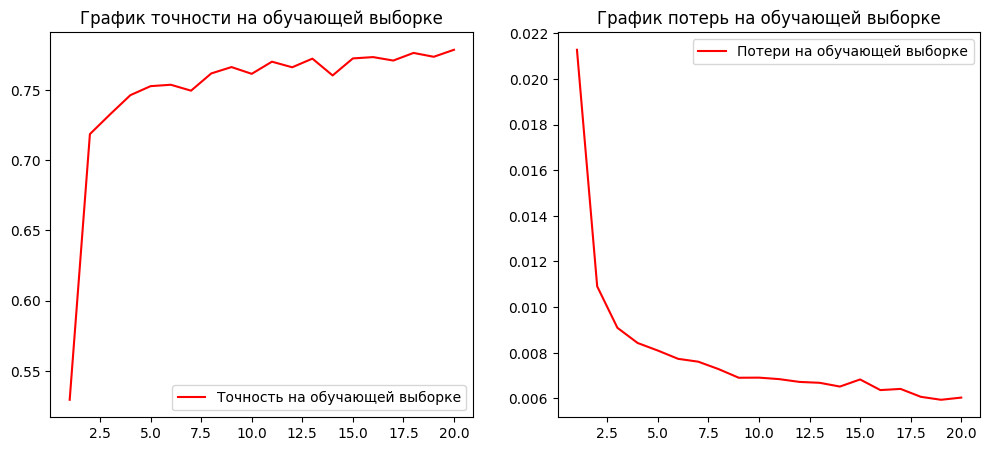

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.7717 - loss: 0.0061
Epoch 1: loss did not improve from 0.00594
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 262ms/step - acc: 0.7648 - loss: 0.0062
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - acc: 0.7677 - loss: 0.0060
Epoch 2: loss improved from 0.00594 to 0.00591, saving model to watermarks.weights.h5

Epoch 2: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step - acc: 0.7703 - loss: 0.0059
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - acc: 0.7754 - loss: 0.0061
Epoch 3: loss improved from 0.00591 to 0.00589, saving model to watermarks.weights.h5

Epoch 3: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - acc: 0.7749 - loss: 0.0059
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - acc: 0.7684 - loss: 0.0057
Epoch 4: loss improved from 0.00589 to 0.00578, saving model to watermarks.weights.h5

Epoch 4: finished saving model to watermarks.we

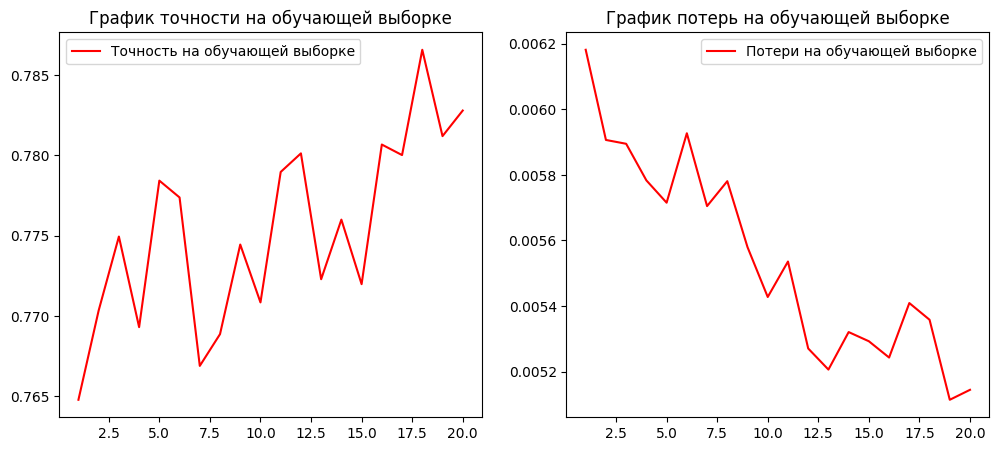

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - acc: 0.7656 - loss: 0.0047
Epoch 1: loss improved from 0.00511 to 0.00488, saving model to watermarks.weights.h5

Epoch 1: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - acc: 0.7754 - loss: 0.0049
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - acc: 0.7727 - loss: 0.0050
Epoch 2: loss improved from 0.00488 to 0.00483, saving model to watermarks.weights.h5

Epoch 2: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 279ms/step - acc: 0.7686 - loss: 0.0048
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - acc: 0.7752 - loss: 0.0047
Epoch 3: loss improved from 0.00483 to 0.00482, saving model to watermarks.weights.h5

Epoch 3: finished saving model to watermarks.weights.h5
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - acc: 0.7745 - loss: 0.0048
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - acc: 0.7591 - loss: 0.0048
Epoch 4: loss did not improve from

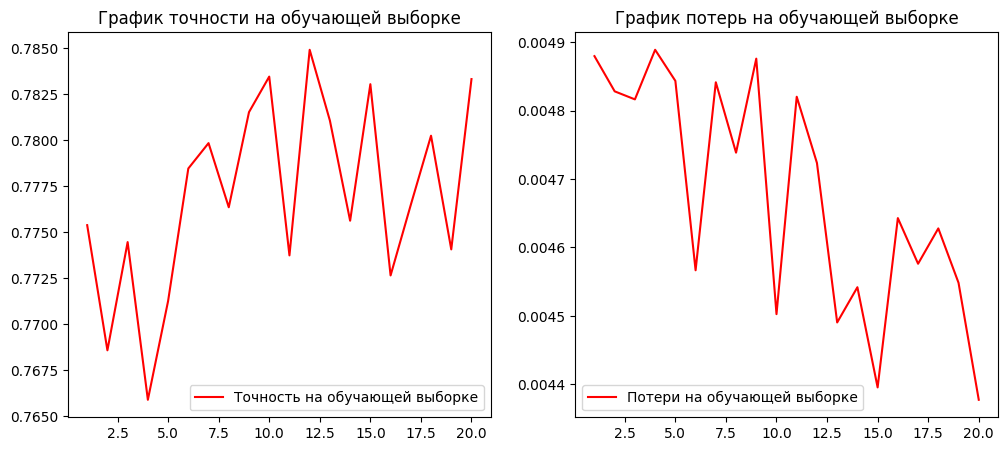

In [ ]:
for i in range(3):
    for file_no in sorted(os.listdir(train_path_no))[(num_images_to_load * i):(num_images_to_load * (i + 1))]:
        train_nonwatermarked.append(os.path.join(train_path_no, file_no))
    y_train = createPixelArr(train_nonwatermarked) # подготовка картинок (без знаков, обучающая выборка)

    data_augmented_y = []

    for image in y_train:
        data_augmented_y.append(data_augmentation(image))

    train_nonwatermarked = []

    y_train = np.append(y_train, data_augmented_y, axis=0)
    X_train = add_watermark(y_train, text="someword")

    del data_augmented_y
    gc.collect()

    X_train = X_train.astype('float32') / 255.
    y_train = y_train.astype('float32') / 255.

    # new_lr = watermark_auto_encoder.optimizer.learning_rate.numpy() * (1 - 0.9 ** i)
    # watermark_auto_encoder.optimizer.learning_rate.assign(new_lr)


    history = watermark_auto_encoder.fit(X_train, y_train,
                                     batch_size=32,
                                     epochs=20,
                                     callbacks=[early_stop, checkpoint])
    #validation_data=(X_test, y_test),

    del X_train, y_train
    gc.collect()

    acc = history.history['acc']              # данные о точности на обучающей выборке
    loss = history.history['loss']            # данные об ошибке на обучающей выборке
    epochs = range(1, len(acc) + 1)           # массив со значениями для оси абсцисс (Х)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'r', label='Точность на обучающей выборке')          #  строим график точность на обучающей выборке
    plt.title('График точности на обучающей выборке')           #  заголовок графика
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'r', label='Потери на обучающей выборке')           #  строим график потерь (ошибки) на обучающей выборке
    plt.title('График потерь на обучающей выборке')             #  заголовок графика
    plt.legend()
    plt.show()

In [ ]:
for file_no in sorted(os.listdir(valid_path_no))[:10]:
    valid_nonwatermarked.append(os.path.join(valid_path_no, file_no))
y_test = createPixelArr(valid_nonwatermarked)  # подготовка картинок (без знаков, контрольная выборка)
X_test = add_watermark(y_test,  text="metka")
X_test = X_test.astype('float32') / 255.
y_test = y_test.astype('float32') / 255.
valid_nonwatermarked = None

In [ ]:
result = watermark_auto_encoder.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


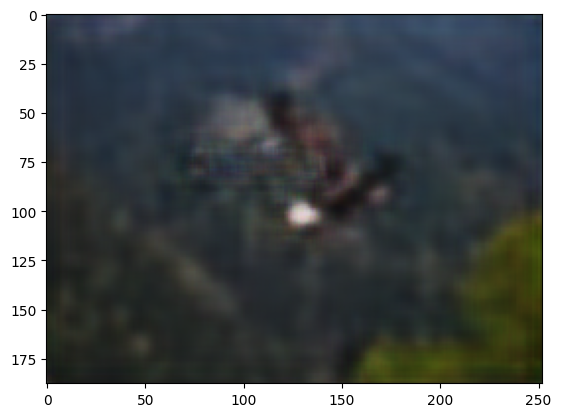

In [ ]:
plt.imshow(cv2.cvtColor(result[1], cv2.COLOR_BGR2RGB))

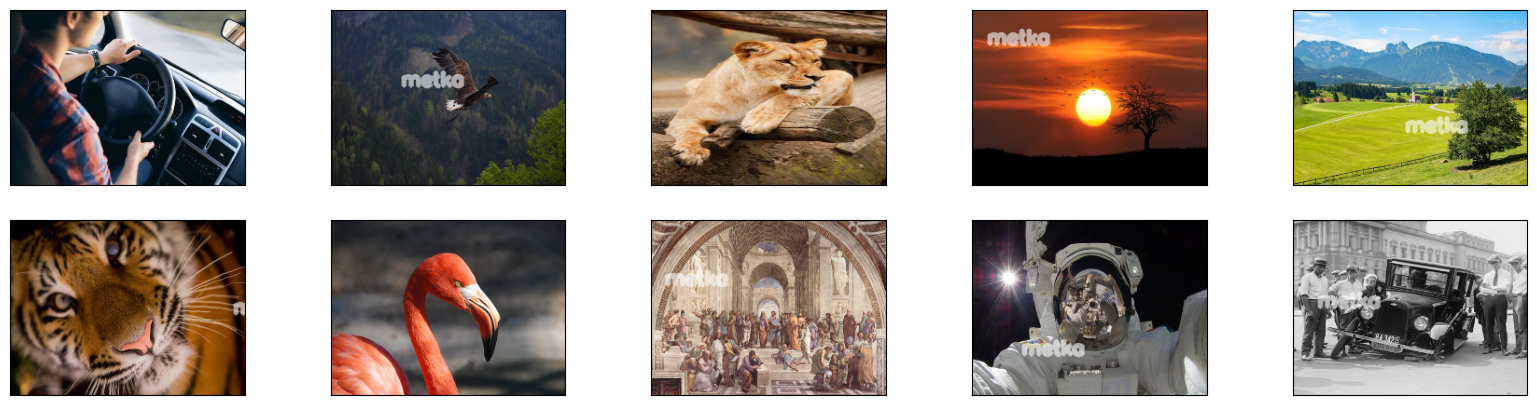

In [ ]:
plt.figure(figsize=(20, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(cv2.cvtColor(X_test[i].astype('float32'), cv2.COLOR_BGR2RGB))
plt.show()

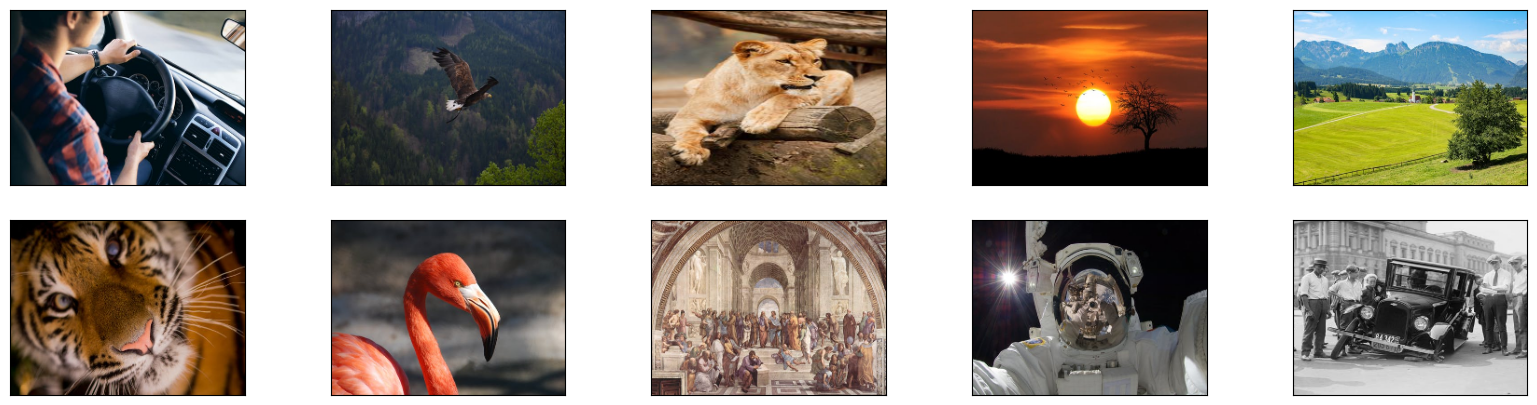

In [ ]:
plt.figure(figsize=(20, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(cv2.cvtColor(y_test[i].astype('float32'), cv2.COLOR_BGR2RGB))
plt.show()

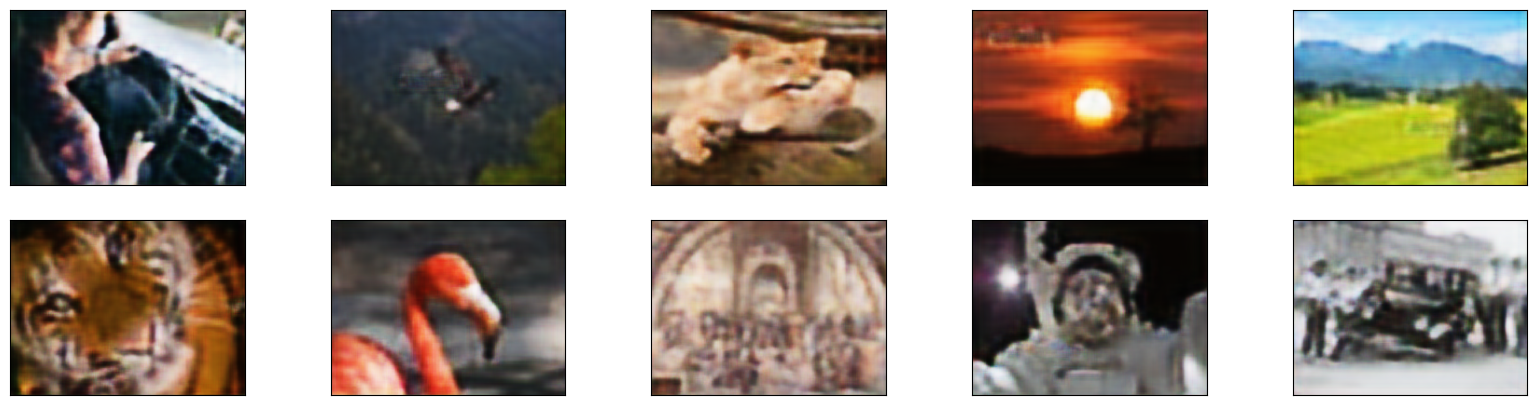

In [ ]:
plt.figure(figsize=(20, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(cv2.cvtColor(result[i], cv2.COLOR_BGR2RGB))
plt.show()

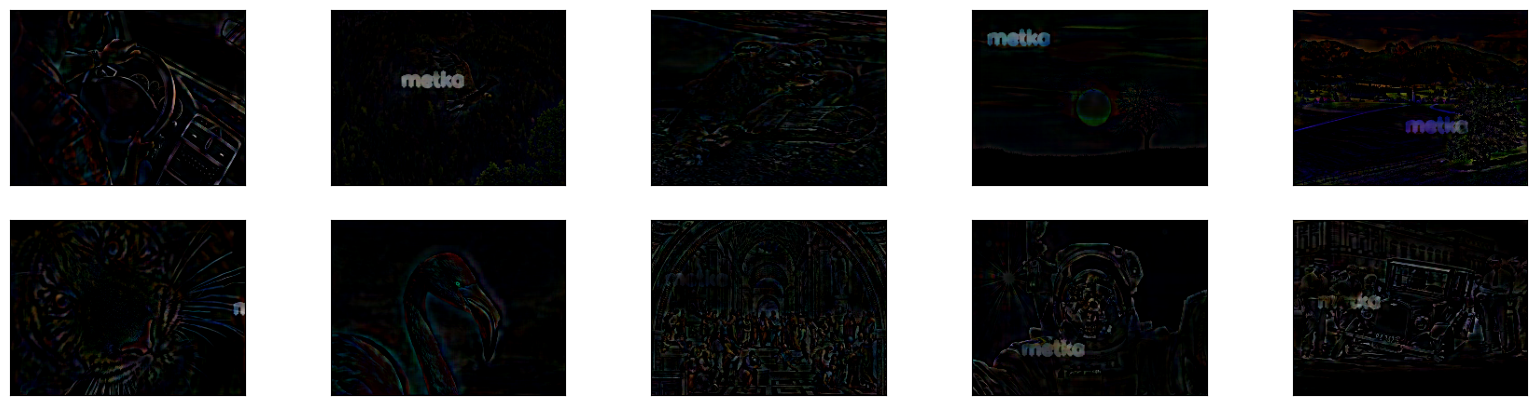

In [ ]:
plt.figure(figsize=(20, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(cv2.cvtColor((X_test[i].astype('float32') - result[i]), cv2.COLOR_BGR2RGB))
plt.show()

На некоторых картинках метку видно очень хорошо - значит она распозналась правильно. На некоторых нейросеть ее не обнаружила. Некоторые метки специально были размещены в крайнее положение, чтобы они получились разной длины (в том числе и 0)